# 🏅 Olympics Data Analysis

---

### Variables
- **Country data:** `Country`, `Code`, `Population`, `GDP per Capita`
- **Athlete data:** `Name`, `Sex`, `Age`, `Height`, `Weight`, `Team`, `NOC`, `Year`, `Season`, `Sport`, `Event`, `Medal`
- **Derived:** `BMI`, `Won_Medal`, `PT_Share`, `GDP_Tier`, `Medal_Rate`, `Log_Population`
---
### Sections
1. Imports & Configuration
2. Data Loading & Initial Inspection
3. Data Quality Report
4. Data Cleaning
5. Exploratory Data Analysis
6. Statistical Analysis
7. Time-Series & Trend Analysis
8. Country Economics × Olympic Performance
9. Conclusions & Interpretation

---
## 1. Imports & Configuration

In [1]:
# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Global plot style
plt.rcParams.update({
    'figure.dpi'        : 120,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.25,
    'font.size'         : 11,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
})

# Colour palettes
MEDAL_COLORS = {
    'Gold'    : '#FFD700',
    'Silver'  : '#C0C0C0',
    'Bronze'  : '#CD7F32',
    'No Medal': '#ECEFF1',
}
SEX_COLORS   = {'M': '#378ADD', 'F': '#E24B4A'}
SEASON_COLORS= {'Summer': '#E24B4A', 'Winter': '#378ADD'}
GDP_COLORS   = ['#1D9E75', '#BA7517', '#378ADD', '#E24B4A']

print('✅ Libraries loaded & style configured')

✅ Libraries loaded & style configured


---
## 2. Data Loading & Initial Inspection

In [2]:
# Load datasets
cou_df = pd.read_csv('country_economics.csv')
ath_df = pd.read_csv('athlete_events.csv')

print('country_economics.csv')
print(f'  Shape   : {cou_df.shape}')
print(f'  Columns : {list(cou_df.columns)}')

print('\nathlete_events.csv')
print(f'  Shape   : {ath_df.shape}')
print(f'  Columns : {list(ath_df.columns)}')
print(f'  Year range: {ath_df.Year.min()} → {ath_df.Year.max()}')
print(f'  Unique NOCs: {ath_df.NOC.nunique()} | Unique Sports: {ath_df.Sport.nunique()}')

country_economics.csv
  Shape   : (201, 4)
  Columns : ['Country', 'Code', 'Population', 'GDP per Capita']

athlete_events.csv
  Shape   : (271116, 15)
  Columns : ['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games', 'Year', 'Season', 'City', 'Sport', 'Event', 'Medal']
  Year range: 1896 → 2016
  Unique NOCs: 230 | Unique Sports: 66


In [3]:
cou_df.head(10)

,Country,Code,Population,GDP per Capita
0,Afghanistan,AFG,32526562.0,594.323081
1,Albania,ALB,2889167.0,3945.217582
2,Algeria,ALG,39666519.0,4206.031232
3,American Samoa*,ASA,55538.0,NaN
4,Andorra,AND,70473.0,NaN
5,Angola,ANG,25021974.0,4101.472152
6,Antigua and Barbuda,ANT,91818.0,13714.731962
7,Argentina,ARG,43416755.0,13431.878340
8,Armenia,ARM,3017712.0,3489.127690
9,Aruba*,ARU,103889.0,NaN


In [4]:
ath_df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


---
## 3. Data Quality Report

In [5]:
# Missing-value
def quality_report(df, name):
    missing    = df.isnull().sum()
    pct        = (missing / len(df) * 100).round(2)
    unique     = df.nunique()
    dtypes     = df.dtypes
    report     = pd.DataFrame({
        'dtype'       : dtypes,
        'missing'     : missing,
        'missing_%'   : pct,
        'unique_vals' : unique,
    })
    print(f'{'='*55}')
    print(f'  QUALITY REPORT — {name}')
    print(f'  Rows: {len(df):,} | Cols: {len(df.columns)} | Duplicates: {df.duplicated().sum():,}')
    print(f'{'='*55}')
    display(report)
    return pct

cou_pct = quality_report(cou_df, 'country_economics.csv')

  QUALITY REPORT — country_economics.csv
  Rows: 201 | Cols: 4 | Duplicates: 0


,dtype,missing,missing_%,unique_vals
Country,object,0,0.00,201
Code,object,0,0.00,201
Population,float64,5,2.49,196
GDP per Capita,float64,25,12.44,176


In [6]:
ath_pct = quality_report(ath_df, 'athlete_events.csv')

  QUALITY REPORT — athlete_events.csv
  Rows: 271,116 | Cols: 15 | Duplicates: 1,385


,dtype,missing,missing_%,unique_vals
ID,int64,0,0.00,135571
Name,object,0,0.00,134732
Sex,object,0,0.00,2
Age,float64,9474,3.49,74
Height,float64,60171,22.19,95
Weight,float64,62875,23.19,220
Team,object,0,0.00,1184
NOC,object,0,0.00,230
Games,object,0,0.00,51
Year,int64,0,0.00,35


---
## 4. Data Cleaning

In [7]:
# Clean Country Dataset
clean_df = cou_df.copy()

# Step 1 — Flag & strip asterisks (territories)
clean_df['Is_Territory'] = clean_df['Country'].str.contains(r'\*', regex=True).astype(int)
clean_df['Country']      = clean_df['Country'].str.replace(r'\*', '', regex=True).str.strip()
print(f'✅ Step 1 — Territory flag: {clean_df["Is_Territory"].sum()} territories found')

# Step 2 — Impute Population with overall median
pop_med = clean_df['Population'].median()
clean_df['Population'].fillna(pop_med, inplace=True)
print(f'✅ Step 2 — Population imputed with median ({pop_med:,.0f})')

# Step 3 — Impute GDP per group (territory vs country)
for flag in [0, 1]:
    med  = clean_df.loc[clean_df['Is_Territory']==flag, 'GDP per Capita'].median()
    mask = (clean_df['Is_Territory']==flag) & (clean_df['GDP per Capita'].isna())
    clean_df.loc[mask, 'GDP per Capita'] = med
    label = 'Territory' if flag else 'Country'
    print(f'✅ Step 3 — GDP imputed for {label} group  (median = ${med:,.2f})')

# Step 4 — Derived features
gdp_bins   = [0, 2000, 10000, 30000, np.inf]
gdp_labels = ['Low (<$2k)', 'Lower-Mid ($2k–$10k)', 'Upper-Mid ($10k–$30k)', 'High (>$30k)']
clean_df['GDP_Tier']       = pd.cut(clean_df['GDP per Capita'], bins=gdp_bins, labels=gdp_labels)
clean_df['Log_Population'] = np.log10(clean_df['Population'])
print('✅ Step 4 — GDP_Tier & Log_Population columns added')

print(f'\n  Remaining nulls: {clean_df.isnull().sum().sum()}')
clean_df.head(8)

✅ Step 1 — Territory flag: 8 territories found
✅ Step 2 — Population imputed with median (7,450,124)
✅ Step 3 — GDP imputed for Country group  (median = $5,232.02)
✅ Step 3 — GDP imputed for Territory group  (median = $42,327.84)
✅ Step 4 — GDP_Tier & Log_Population columns added

  Remaining nulls: 0


,Country,Code,Population,GDP per Capita,Is_Territory,GDP_Tier,Log_Population
0,Afghanistan,AFG,32526562.0,594.323081,0,Low (<$2k),7.512238
1,Albania,ALB,2889167.0,3945.217582,0,Lower-Mid ($2k–$10k),6.460773
2,Algeria,ALG,39666519.0,4206.031232,0,Lower-Mid ($2k–$10k),7.598424
3,American Samoa,ASA,55538.0,42327.839957,1,High (>$30k),4.744590
4,Andorra,AND,70473.0,5232.024583,0,Lower-Mid ($2k–$10k),4.848023
5,Angola,ANG,25021974.0,4101.472152,0,Lower-Mid ($2k–$10k),7.398322
6,Antigua and Barbuda,ANT,91818.0,13714.731962,0,Upper-Mid ($10k–$30k),4.962928
7,Argentina,ARG,43416755.0,13431.878340,0,Upper-Mid ($10k–$30k),7.637657


In [8]:
# Clean Athlete Dataset
ath = ath_df.copy()

# Step 1 — Drop exact duplicates
before = len(ath)
ath.drop_duplicates(inplace=True)
ath.reset_index(drop=True, inplace=True)
print(f'✅ Step 1 — Removed {before - len(ath):,} duplicate rows  → {len(ath):,} remain')

# Step 2 — Medal: NaN → "No Medal"
ath['Medal'] = ath['Medal'].fillna('No Medal')
print('✅ Step 2 — Medal NaN → "No Medal"')

# Step 3 — Impute numerical columns with median
for col in ['Age', 'Height', 'Weight']:
    med = ath[col].median()
    ath[col].fillna(med, inplace=True)
    print(f'✅ Step 3 — {col} imputed with median ({med})')

# Step 4 — Derived columns
ath['BMI']       = (ath['Weight'] / ((ath['Height'] / 100) ** 2)).round(2)
ath['Won_Medal'] = (ath['Medal'] != 'No Medal').astype(int)
print('✅ Step 4 — BMI and Won_Medal columns added')

# Step 5 — IQR outlier detection for Age (report only, no removal)
Q1, Q3 = ath['Age'].quantile([0.25, 0.75])
IQR    = Q3 - Q1
n_out  = ((ath['Age'] < Q1-1.5*IQR) | (ath['Age'] > Q3+1.5*IQR)).sum()
print(f'⚠️  Step 5 — {n_out:,} age outliers detected (IQR method)  |  range: {ath.Age.min():.0f}–{ath.Age.max():.0f}')

print(f'\n  Final shape : {ath.shape}')
print(f'  Remaining nulls: {ath.isnull().sum().sum()}')
ath[['Name','Sex','Age','Height','Weight','BMI','Medal','Won_Medal']].head()

✅ Step 1 — Removed 1,385 duplicate rows  → 269,731 remain
✅ Step 2 — Medal NaN → "No Medal"
✅ Step 3 — Age imputed with median (24.0)
✅ Step 3 — Height imputed with median (175.0)
✅ Step 3 — Weight imputed with median (70.0)
✅ Step 4 — BMI and Won_Medal columns added
⚠️  Step 5 — 11,059 age outliers detected (IQR method)  |  range: 10–97

  Final shape : (269731, 17)
  Remaining nulls: 0


,Name,Sex,Age,Height,Weight,BMI,Medal,Won_Medal
0,A Dijiang,M,24.0,180.0,80.0,24.69,No Medal,0
1,A Lamusi,M,23.0,170.0,60.0,20.76,No Medal,0
2,Gunnar Nielsen Aaby,M,24.0,175.0,70.0,22.86,No Medal,0
3,Edgar Lindenau Aabye,M,34.0,175.0,70.0,22.86,Gold,1
4,Christine Jacoba Aaftink,F,21.0,185.0,82.0,23.96,No Medal,0


---
## 5. Exploratory Data Analysis

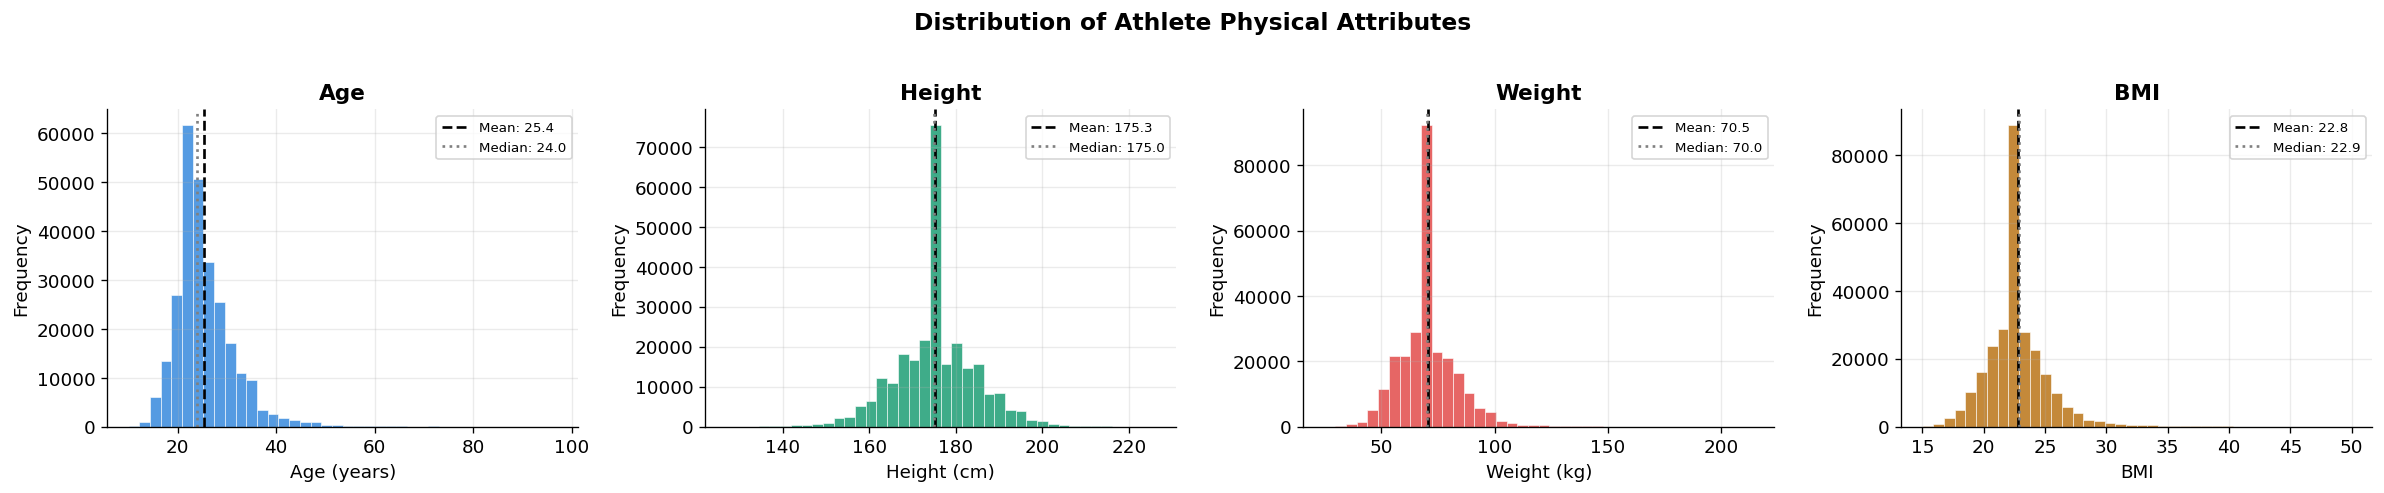

In [9]:
# Distributions: Age, Height, Weight, BMI
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Distribution of Athlete Physical Attributes', fontsize=14, fontweight='bold', y=1.02)

configs = [
    ('Age',    '#378ADD', 'Age (years)'),
    ('Height', '#1D9E75', 'Height (cm)'),
    ('Weight', '#E24B4A', 'Weight (kg)'),
    ('BMI',    '#BA7517', 'BMI'),
]

for ax, (col, color, xlabel) in zip(axes, configs):
    data = ath[col]
    if col == 'BMI':
        data = data[(data >= 15) & (data <= 50)]  # trim extreme BMI
    ax.hist(data, bins=40, color=color, alpha=0.85, edgecolor='white', linewidth=0.4)
    ax.axvline(data.mean(),   color='black', linestyle='--', linewidth=1.6, label=f'Mean: {data.mean():.1f}')
    ax.axvline(data.median(), color='gray',  linestyle=':',  linewidth=1.6, label=f'Median: {data.median():.1f}')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    ax.set_title(col)

plt.tight_layout()
plt.savefig('01_physical_distributions.png', bbox_inches='tight')
plt.show()

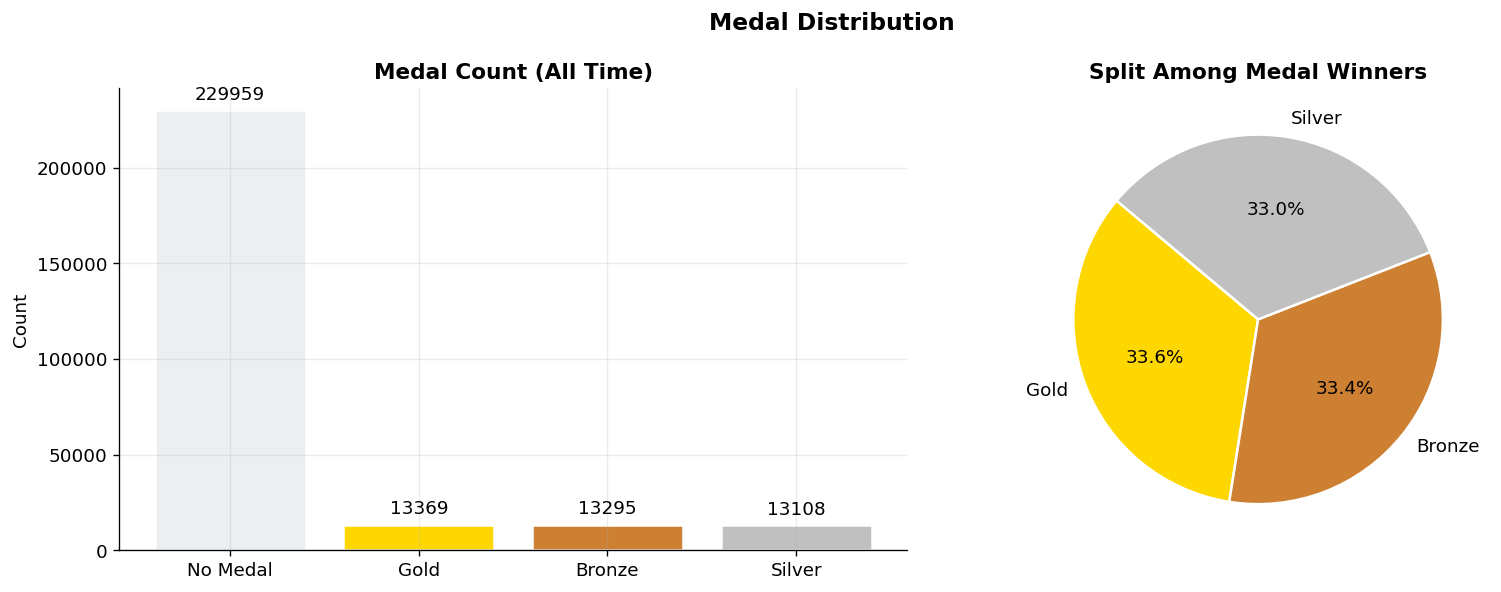

In [10]:
# Medal Category Breakdown
medal_counts = ath['Medal'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Medal Distribution', fontsize=14, fontweight='bold')

# Bar
colors = [MEDAL_COLORS[m] for m in medal_counts.index]
bars = axes[0].bar(medal_counts.index, medal_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].bar_label(bars, fmt='%d', padding=4)
axes[0].set_ylabel('Count')
axes[0].set_title('Medal Count (All Time)')

# Pie — medal winners only
winners = medal_counts.drop('No Medal')
axes[1].pie(winners, labels=winners.index, autopct='%1.1f%%',
            colors=[MEDAL_COLORS[m] for m in winners.index],
            startangle=140, wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Split Among Medal Winners')

plt.tight_layout()
plt.savefig('02_medal_breakdown.png', bbox_inches='tight')
plt.show()

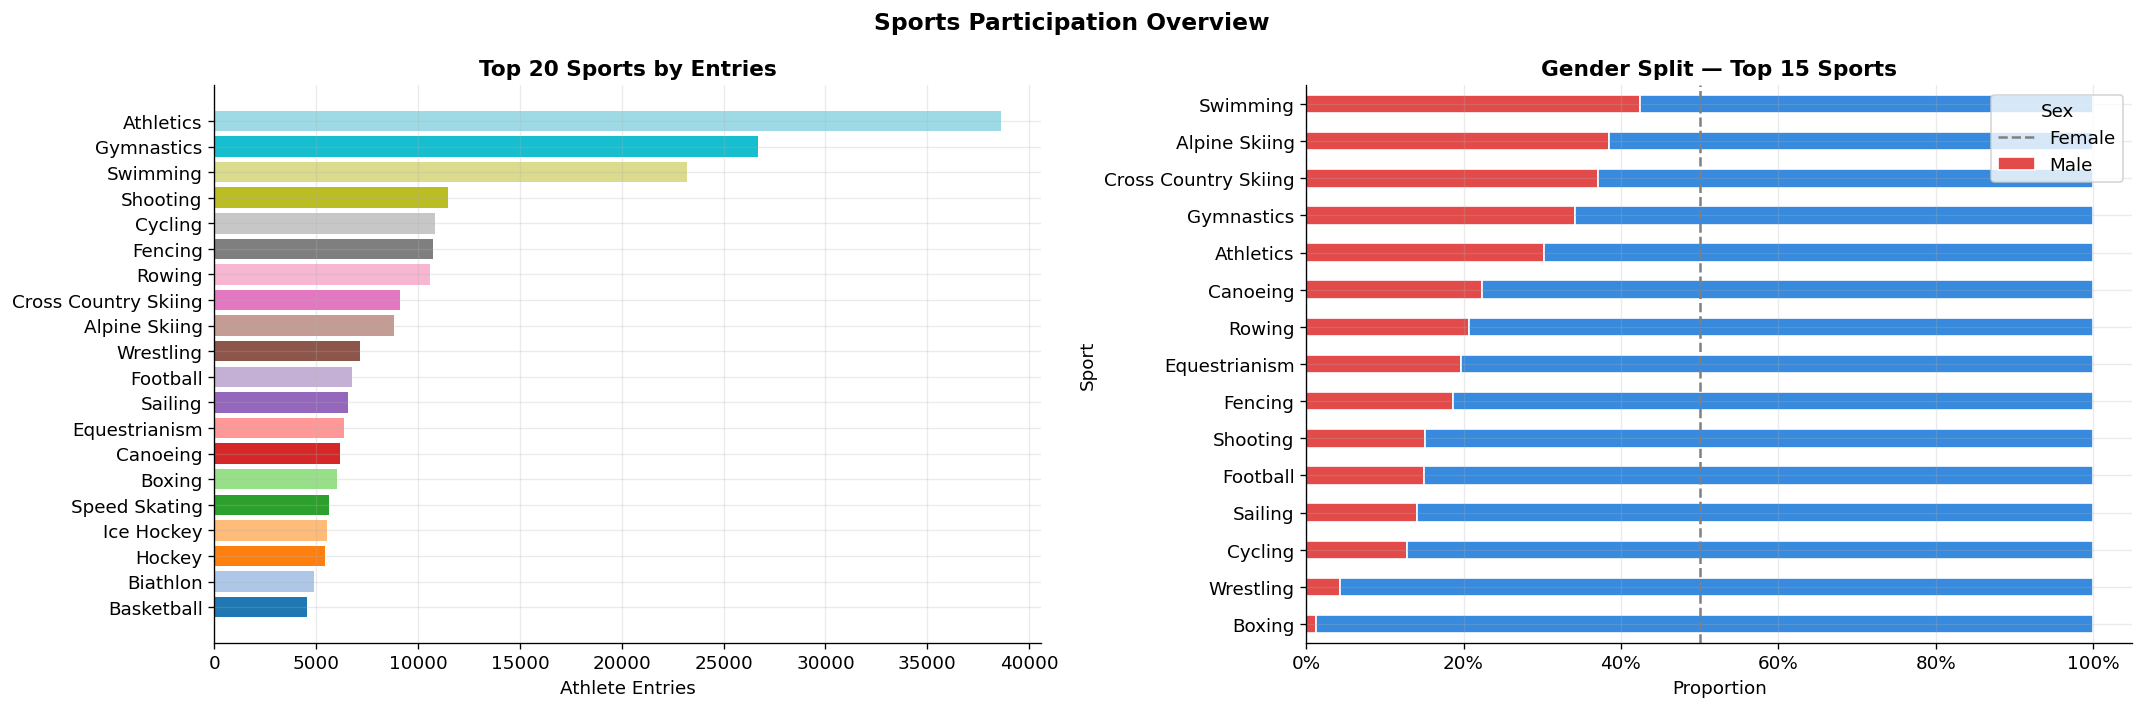

In [11]:
# Gender Split by Top 15 Sports
top15_sports = ath['Sport'].value_counts().head(15).index.tolist()
sex_sport    = ath[ath['Sport'].isin(top15_sports)].groupby(['Sport','Sex']).size().unstack(fill_value=0)
pct_sport    = sex_sport.div(sex_sport.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Sports Participation Overview', fontsize=14, fontweight='bold')

# Top 20 sports by entries
top20_sport = ath['Sport'].value_counts().head(20)
axes[0].barh(top20_sport.index[::-1], top20_sport.values[::-1],
             color=sns.color_palette('tab20', 20))
axes[0].set_title('Top 20 Sports by Entries')
axes[0].set_xlabel('Athlete Entries')

# Gender proportion stacked
pct_sport.sort_values('F' if 'F' in pct_sport.columns else pct_sport.columns[0]).plot(
    kind='barh', stacked=True, ax=axes[1],
    color=[SEX_COLORS.get(c, '#999') for c in pct_sport.columns],
    edgecolor='white')
axes[1].axvline(0.5, color='gray', linestyle='--', lw=1.5, label='50% line')
axes[1].set_title('Gender Split — Top 15 Sports')
axes[1].set_xlabel('Proportion')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].legend(title='Sex', labels=['Female','Male'])

plt.tight_layout()
plt.savefig('04_sports_gender.png', bbox_inches='tight')
plt.show()

---
## 6. Statistical Analysis

In [12]:
# Descriptive stats by Season
season_stats = ath.groupby('Season')[['Age','Height','Weight','BMI','Won_Medal']].agg(
    ['mean','median','std']
).round(2)
print('Descriptive Statistics by Season')
season_stats

Descriptive Statistics by Season


Age               Height              Weight                  BMI  \
         mean median   std    mean median   std   mean median    std   mean   
Season                                                                        
Summer  25.49   24.0  6.31  175.40  175.0  9.59  70.52   70.0  12.93  22.77   
Winter  25.03   24.0  4.76  174.66  175.0  7.83  70.62   70.0  11.02  23.03   

                    Won_Medal               
       median   std      mean median   std  
Season                                      
Summer  22.86  2.66      0.15    0.0  0.36  
Winter  22.86  2.28      0.12    0.0  0.32

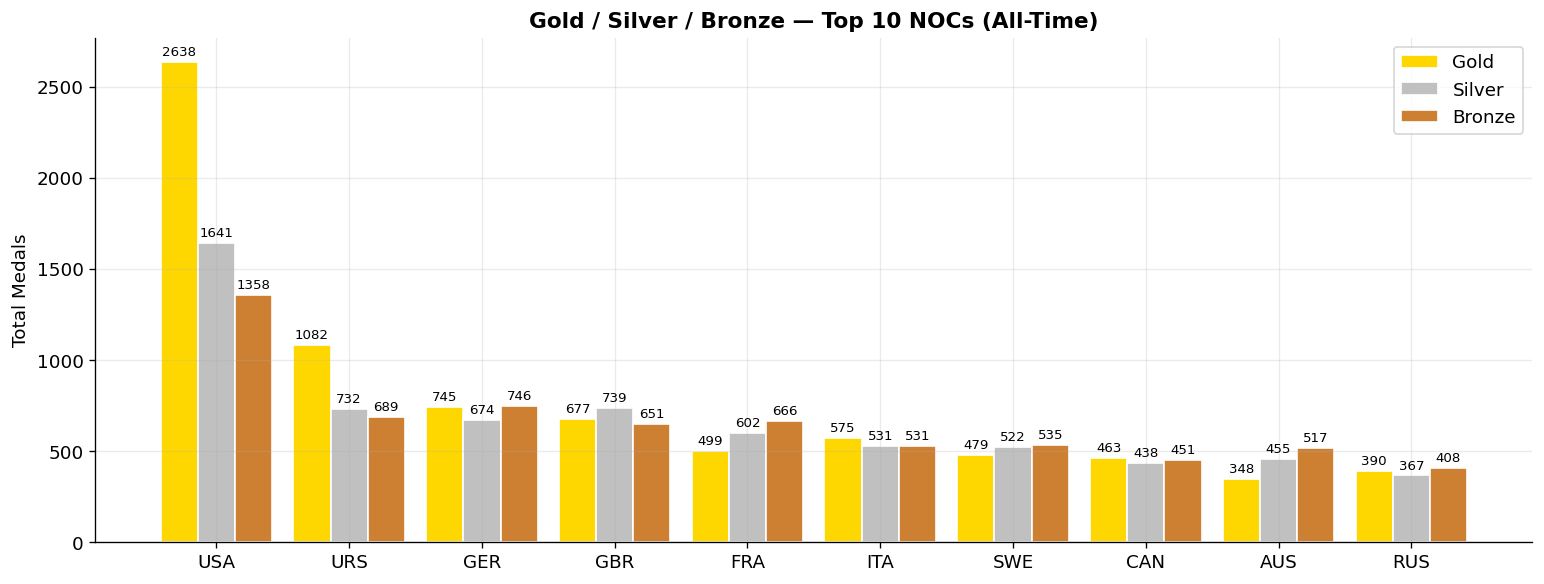

In [13]:
# Top NOC medal counts with Gold/Silver/Bronze breakdown
top10_noc  = ath[ath['Won_Medal']==1]['NOC'].value_counts().head(10).index.tolist()
medal_pivot = ath[ath['NOC'].isin(top10_noc)].groupby(['NOC','Medal']).size().unstack(fill_value=0)
medal_pivot = medal_pivot.reindex(columns=['Gold','Silver','Bronze'], fill_value=0)
medal_pivot = medal_pivot.loc[top10_noc]

fig, ax = plt.subplots(figsize=(13, 5))
x     = np.arange(len(top10_noc))
width = 0.28

b1 = ax.bar(x - width, medal_pivot['Gold'],   width, color='#FFD700', edgecolor='white', label='Gold')
b2 = ax.bar(x,         medal_pivot['Silver'], width, color='#C0C0C0', edgecolor='white', label='Silver')
b3 = ax.bar(x + width, medal_pivot['Bronze'], width, color='#CD7F32', edgecolor='white', label='Bronze')
ax.bar_label(b1, fmt='%d', padding=2, fontsize=8)
ax.bar_label(b2, fmt='%d', padding=2, fontsize=8)
ax.bar_label(b3, fmt='%d', padding=2, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(top10_noc, fontsize=11)
ax.set_ylabel('Total Medals')
ax.set_title('Gold / Silver / Bronze — Top 10 NOCs (All-Time)', fontsize=13, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('07_noc_medals.png', bbox_inches='tight')
plt.show()

---
## 7. Time-Series & Trend Analysis

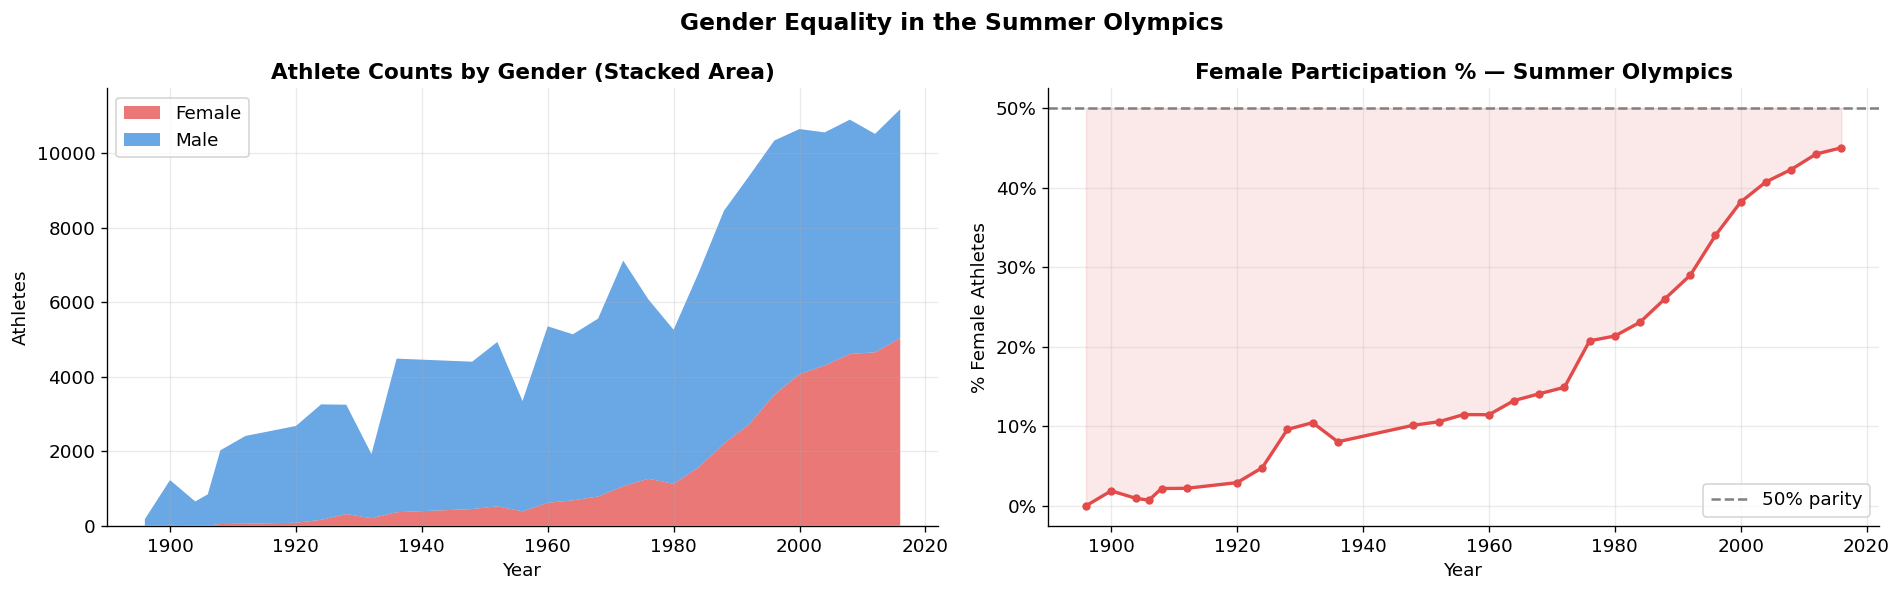

In [14]:
# Gender equality trend
gender_yr = ath[ath['Season']=='Summer'].groupby(['Year','Sex'])['ID'].nunique().unstack(fill_value=0)
pct_f     = (gender_yr.get('F', pd.Series(0, index=gender_yr.index)) /
             gender_yr.sum(axis=1) * 100)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Gender Equality in the Summer Olympics', fontsize=14, fontweight='bold')

# Stacked area
axes[0].stackplot(gender_yr.index,
                  [gender_yr.get('F', pd.Series(0, index=gender_yr.index)),
                   gender_yr.get('M', pd.Series(0, index=gender_yr.index))],
                  labels=['Female','Male'],
                  colors=['#E24B4A','#378ADD'], alpha=0.75)
axes[0].set_title('Athlete Counts by Gender (Stacked Area)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Athletes')
axes[0].legend(loc='upper left')

# % Female line
axes[1].plot(pct_f.index, pct_f.values, color='#E24B4A', marker='o', markersize=4, linewidth=2)
axes[1].axhline(50, color='gray', linestyle='--', lw=1.5, label='50% parity')
axes[1].fill_between(pct_f.index, pct_f.values, 50, alpha=0.12, color='#E24B4A')
axes[1].set_title('Female Participation % — Summer Olympics')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('% Female Athletes')
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.savefig('10_gender_trends.png', bbox_inches='tight')
plt.show()

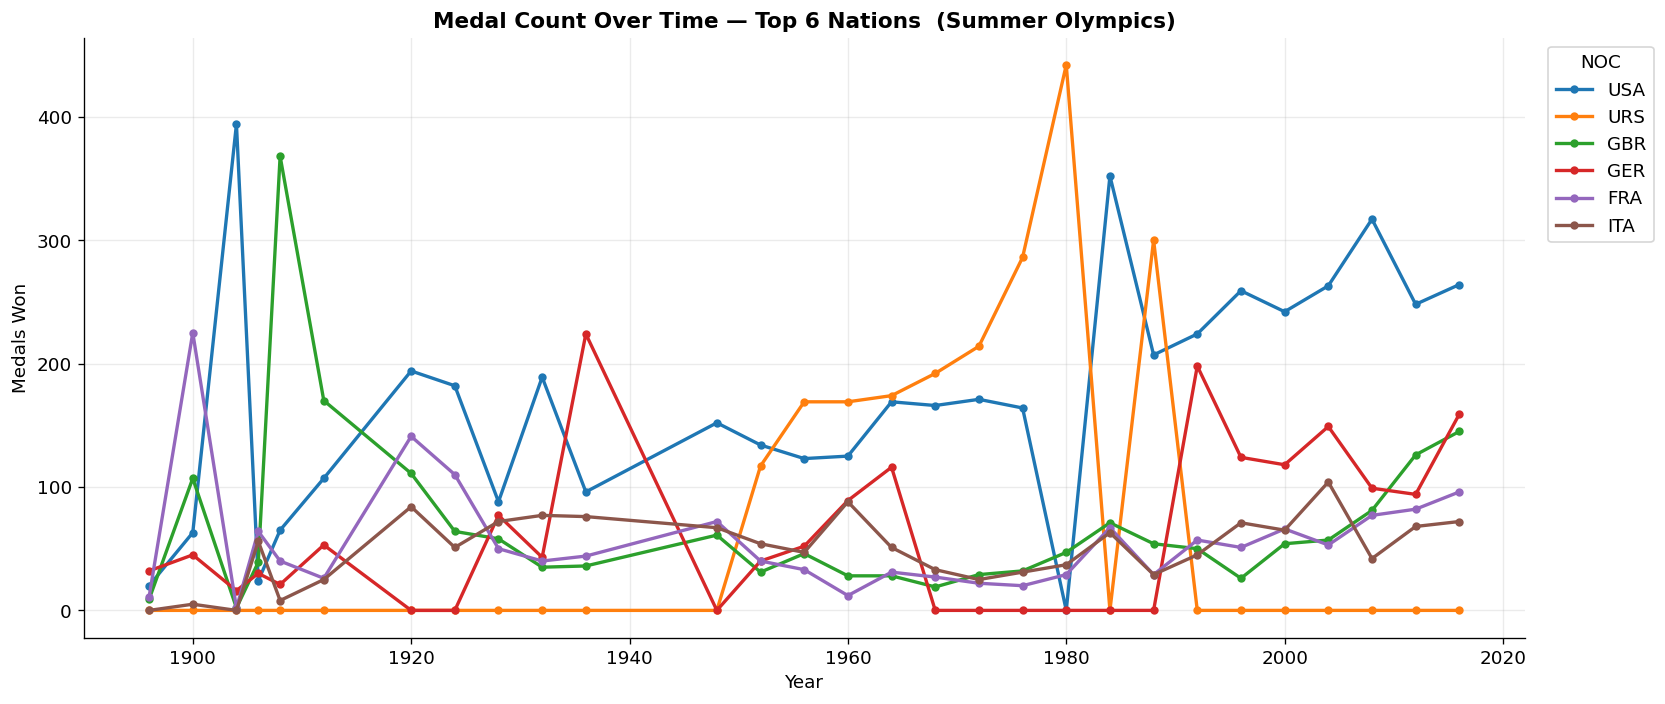

In [15]:
# Medal dominance over time — Top 6 nations
summer = ath[ath['Season']=='Summer']
top6   = summer[summer['Won_Medal']==1]['NOC'].value_counts().head(6).index.tolist()
medal_trend = summer[summer['NOC'].isin(top6)].groupby(['Year','NOC'])['Won_Medal'].sum().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
palette = sns.color_palette('tab10', len(top6))
for noc, color in zip(top6, palette):
    if noc in medal_trend.columns:
        ax.plot(medal_trend.index, medal_trend[noc],
                marker='o', markersize=4, linewidth=2, color=color, label=noc)

ax.set_title('Medal Count Over Time — Top 6 Nations  (Summer Olympics)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Medals Won')
ax.legend(title='NOC', bbox_to_anchor=(1.01,1), loc='upper left')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=8))

plt.tight_layout()
plt.savefig('11_medal_dominance.png', bbox_inches='tight')
plt.show()

---
## 8. Country Economics × Olympic Performance

In [16]:
# Build merged dataset
noc_agg = summer.groupby('NOC').agg(
    Total_Medals  = ('Won_Medal','sum'),
    Gold_Medals   = ('Medal', lambda x: (x=='Gold').sum()),
    Silver_Medals = ('Medal', lambda x: (x=='Silver').sum()),
    Bronze_Medals = ('Medal', lambda x: (x=='Bronze').sum()),
    Total_Athletes= ('ID','nunique'),
    Unique_Sports = ('Sport','nunique'),
    Games_Entered = ('Games','nunique'),
).reset_index()

noc_agg['Medal_Rate'] = (noc_agg['Total_Medals'] / noc_agg['Total_Athletes']).round(3)

merged = noc_agg.merge(clean_df, left_on='NOC', right_on='Code', how='inner')
print(f'Merged rows: {len(merged)}')
merged[['Country','NOC','Total_Medals','Gold_Medals','Medal_Rate',
        'GDP per Capita','Population','GDP_Tier']].head(10)

Merged rows: 198


,Country,NOC,Total_Medals,Gold_Medals,Medal_Rate,GDP per Capita,Population,GDP_Tier
0,Afghanistan,AFG,2,0,0.019,594.323081,32526562.0,Low (<$2k)
1,Netherlands Antilles,AHO,1,0,0.019,42327.839957,7450123.5,High (>$30k)
2,Albania,ALB,0,0,0.000,3945.217582,2889167.0,Lower-Mid ($2k–$10k)
3,Algeria,ALG,17,5,0.046,4206.031232,39666519.0,Lower-Mid ($2k–$10k)
4,Andorra,AND,0,0,0.000,5232.024583,70473.0,Lower-Mid ($2k–$10k)
5,Angola,ANG,0,0,0.000,4101.472152,25021974.0,Lower-Mid ($2k–$10k)
6,Antigua and Barbuda,ANT,0,0,0.000,13714.731962,91818.0,Upper-Mid ($10k–$30k)
7,Argentina,ARG,274,91,0.160,13431.878340,43416755.0,Upper-Mid ($10k–$30k)
8,Armenia,ARM,16,2,0.136,3489.127690,3017712.0,Lower-Mid ($2k–$10k)
9,Aruba,ARU,0,0,0.000,42327.839957,103889.0,High (>$30k)


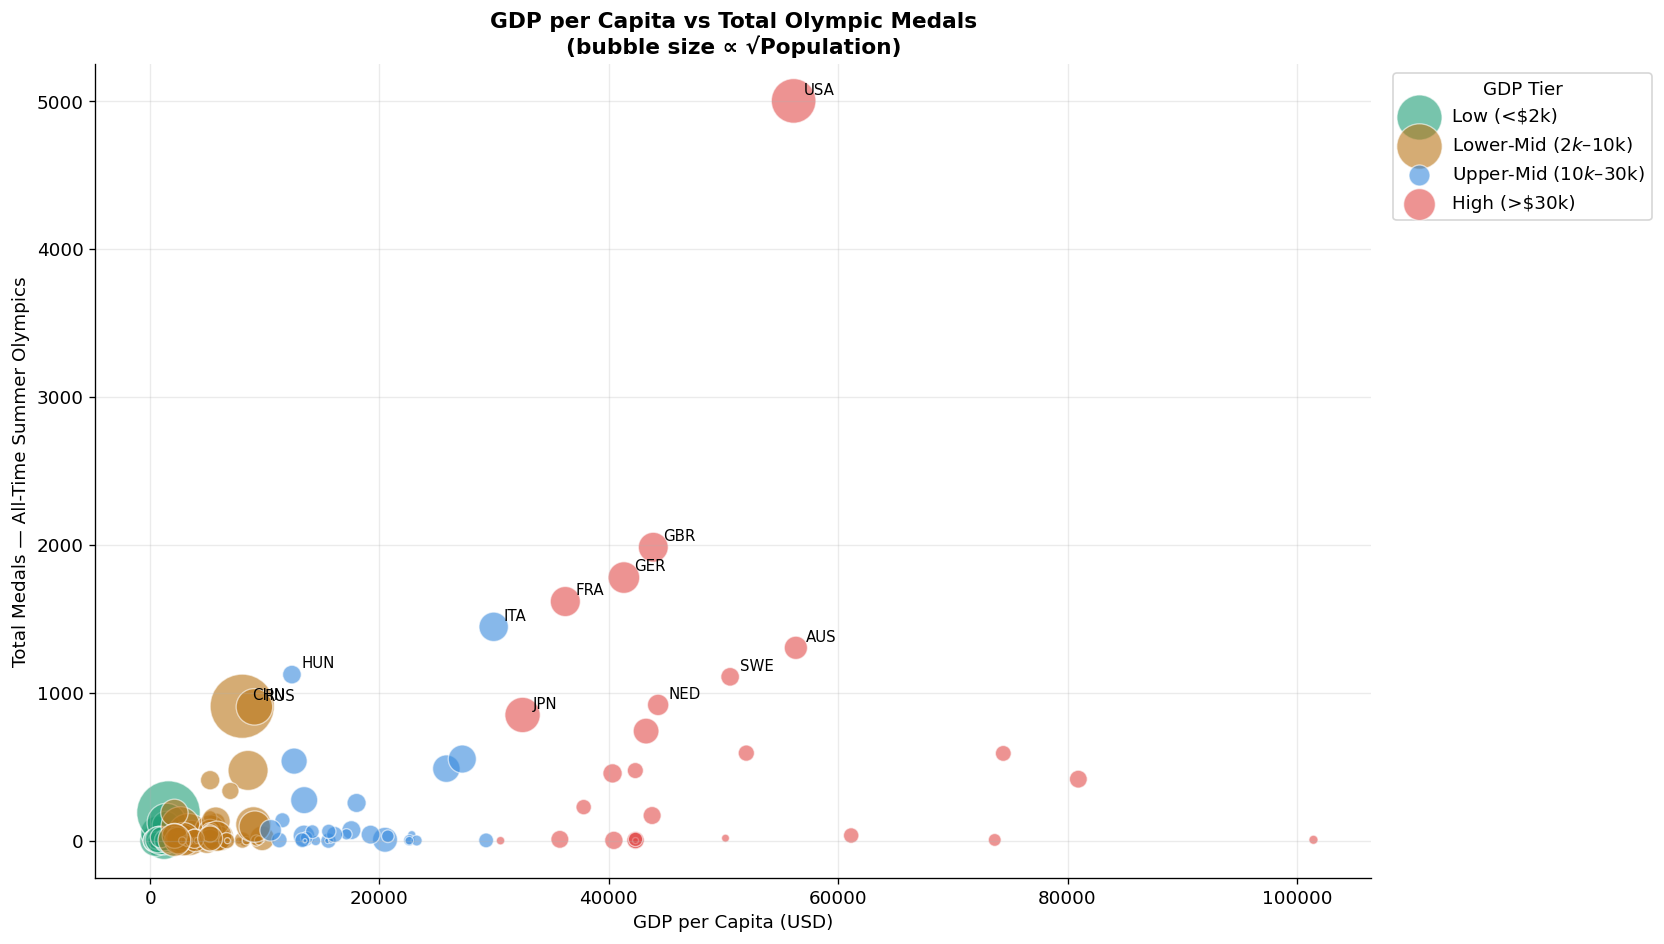

In [17]:
import numpy as np

# Bubble chart: GDP x Medals, bubble size = Population
fig, ax = plt.subplots(figsize=(14, 8))

tiers = gdp_labels # Define tiers using the previously defined gdp_labels
for tier, color in zip(tiers, GDP_COLORS):
    sub = merged[merged['GDP_Tier']==tier]
    ax.scatter(sub['GDP per Capita'], sub['Total_Medals'],
               s=np.sqrt(sub['Population']) / 25,
               color=color, alpha=0.6, edgecolors='w', linewidth=0.8, label=tier)

# Label standout countries
for _, row in merged.nlargest(12,'Total_Medals').iterrows():
    ax.annotate(row['NOC'],
                xy=(row['GDP per Capita'], row['Total_Medals']),
                xytext=(6, 4), textcoords='offset points', fontsize=9)

ax.set_title('GDP per Capita vs Total Olympic Medals\n(bubble size ∝ √Population)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('GDP per Capita (USD)')
ax.set_ylabel('Total Medals — All-Time Summer Olympics')
ax.legend(title='GDP Tier', bbox_to_anchor=(1.01,1), loc='upper left')

plt.tight_layout()
plt.savefig('15_bubble_chart.png', bbox_inches='tight')
plt.show()

---
## 9. Medal Prediction Model
---
A **Random Forest classifier** trained on athlete-level features (Age, BMI, Height, Weight, Sex, Season, GDP Tier, Country and Sport historical medal rates) to predict medal probability.

Includes: feature importance table, classification report, confusion matrix, and a live `predict_medal()` function you can call on any custom athlete profile.

In [18]:
# Medal Prediction Model
from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics         import classification_report, confusion_matrix, roc_auc_score
import pandas as pd
import numpy  as np

print('=' * 60)
print('  MEDAL PREDICTION MODEL  —  Random Forest Classifier')
print('=' * 60)

# 1. Feature Engineering
model_df = ath.copy()

# Merge clean_df to get GDP_Tier
model_df = model_df.merge(clean_df[['Code', 'GDP_Tier']], left_on='NOC', right_on='Code', how='left')
model_df.drop(columns=['Code'], inplace=True)

model_df['Sex_enc']    = (model_df['Sex'] == 'M').astype(int)
model_df['Season_enc'] = (model_df['Season'] == 'Summer').astype(int)

noc_rate   = model_df.groupby('NOC')['Won_Medal'].mean().rename('NOC_Medal_Rate')
model_df   = model_df.join(noc_rate, on='NOC')

sport_rate = model_df.groupby('Sport')['Won_Medal'].mean().rename('Sport_Medal_Rate')
model_df   = model_df.join(sport_rate, on='Sport')

gdp_order  = {'Low (<$2k)': 0, 'Lower-Mid ($2k–$10k)': 1, 'Upper-Mid ($10k–$30k)': 2, 'High (>$30k)': 3}
model_df['GDP_Tier_enc'] = model_df['GDP_Tier'].map(gdp_order).fillna(1)

FEATURES = ['Age', 'Height', 'Weight', 'BMI',
            'Sex_enc', 'Season_enc',
            'NOC_Medal_Rate', 'Sport_Medal_Rate', 'GDP_Tier_enc']
TARGET   = 'Won_Medal'

ml_data = model_df[FEATURES + [TARGET]].dropna()
X       = ml_data[FEATURES]
y       = ml_data[TARGET]

print(f'\n  Dataset : {len(ml_data):,} rows  |  Medal winners: {y.mean()*100:.1f}%')

# 2. Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'  Train   : {len(X_train):,}  |  Test: {len(X_test):,}')

# 3. Train Model
rf = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=20,
    class_weight='balanced', n_jobs=-1, random_state=42
)
rf.fit(X_train, y_train)

y_pred    = rf.predict(X_test)
y_prob    = rf.predict_proba(X_test)[:, 1]
roc_auc   = roc_auc_score(y_test, y_prob)
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='roc_auc', n_jobs=-1)

print(f'\n  ROC-AUC  (test)      : {roc_auc:.4f}')
print(f'  ROC-AUC  (5-fold CV) : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

# 4. Classification Report
print('\n' + '-' * 60)
print('Classification Report')
print('-' * 60)
print(classification_report(y_test, y_pred, target_names=['No Medal', 'Medal']))

# 5. Feature Importance Table
FEATURE_LABELS = {
    'Age'              : 'Age (years)',
    'Height'           : 'Height (cm)',
    'Weight'           : 'Weight (kg)',
    'BMI'              : 'BMI',
    'Sex_enc'          : 'Sex  (M=1)',
    'Season_enc'       : 'Season  (Summer=1)',
    'NOC_Medal_Rate'   : 'Country Historical Medal Rate',
    'Sport_Medal_Rate' : 'Sport Historical Medal Rate',
    'GDP_Tier_enc'     : 'GDP Tier  (0=Low, 3=High)',
}

importance_df = pd.DataFrame({
    'Feature'      : [FEATURE_LABELS[f] for f in FEATURES],
    'Importance'   : rf.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

importance_df['Importance %'] = (importance_df['Importance'] * 100).round(2)
importance_df['Rank']         = range(1, len(importance_df) + 1)
importance_df['Bar']          = importance_df['Importance %'].apply(
    lambda x: chr(9608) * max(1, int(x / 2))
)

print('-' * 60)
print('Feature Importance (sorted by contribution)')
print('-' * 60)
print(importance_df[['Rank', 'Feature', 'Importance %', 'Bar']].to_string(index=False))

# 6. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print('\n' + '-' * 60)
print('Confusion Matrix')
print('-' * 60)
print(f'                   Predicted No Medal   Predicted Medal')
print(f'  Actual No Medal       {cm[0,0]:>8,}          {cm[0,1]:>8,}')
print(f'  Actual Medal          {cm[1,0]:>8,}          {cm[1,1]:>8,}')

# 7. Live Prediction Function
def predict_medal(age, height_cm, weight_kg, sex='M', season='Summer',
                  noc='USA', sport='Athletics', gdp_tier='High (>$30k)'):
    """
    Predict medal probability for a single custom athlete profile.

    Parameters
    ----------
    age        : int/float  — athlete age
    height_cm  : float      — height in centimetres
    weight_kg  : float      — weight in kilograms
    sex        : str        — 'M' or 'F'
    season     : str        — 'Summer' or 'Winter'
    noc        : str        — 3-letter NOC code  (e.g. 'USA', 'CHN', 'IND')
    sport      : str        — Sport name  (e.g. 'Swimming', 'Gymnastics')
    gdp_tier   : str        — 'Low (<$2k)' | 'Lower-Mid ($2k–$10k)' | 'Upper-Mid ($10k–$30k)' | 'High (>$30k)'

    Returns
    -------
    dict  — medal_probability, predicted_outcome, top_3_factors
    """
    bmi          = weight_kg / ((height_cm / 100) ** 2)
    sex_enc      = 1 if sex == 'M' else 0
    season_enc   = 1 if season == 'Summer' else 0
    noc_rate_v   = noc_rate.get(noc,   noc_rate.mean())
    sport_rate_v = sport_rate.get(sport, sport_rate.mean())
    gdp_enc      = gdp_order.get(gdp_tier, 1)

    row  = pd.DataFrame([{
        'Age': age, 'Height': height_cm, 'Weight': weight_kg, 'BMI': bmi,
        'Sex_enc': sex_enc, 'Season_enc': season_enc,
        'NOC_Medal_Rate': noc_rate_v, 'Sport_Medal_Rate': sport_rate_v,
        'GDP_Tier_enc': gdp_enc
    }])

    prob    = rf.predict_proba(row)[0, 1]
    outcome = 'MEDAL' if prob >= 0.5 else 'No Medal'
    top3    = importance_df[['Feature', 'Importance %']].head(3).values.tolist()

    return {
        'medal_probability': round(float(prob), 4),
        'predicted_outcome': outcome,
        'top_3_factors'    : top3
    }

# 8. Demo Predictions
print('\n' + '-' * 60)
print('Demo Predictions')
print('-' * 60)
demos = [
    dict(age=24, height_cm=185, weight_kg=80,  sex='M', season='Summer',
         noc='USA', sport='Swimming',   gdp_tier='High (>$30k)'),
    dict(age=19, height_cm=158, weight_kg=52,  sex='F', season='Summer',
         noc='CHN', sport='Gymnastics', gdp_tier='Upper-Mid ($10k–$30k)'),
    dict(age=32, height_cm=172, weight_kg=68,  sex='M', season='Summer',
         noc='IND', sport='Athletics',  gdp_tier='Lower-Mid ($2k–$10k)'),
    dict(age=27, height_cm=176, weight_kg=73,  sex='F', season='Winter',
         noc='NOR', sport='Skiing',     gdp_tier='High (>$30k)'),
]
print(f'  {"NOC":<5} {"Sport":<14} {"Age":<5} {"Prob":>7}   Outcome')
print('  ' + '-' * 46)
for d in demos:
    res = predict_medal(**d)
    print(f"  {d['noc']:<5} {d['sport']:<14} {d['age']:<5} "
          f"{res['medal_probability']:>6.1%}   {res['predicted_outcome']}")

print('\n  predict_medal() is ready — call it with any custom athlete profile.')

  MEDAL PREDICTION MODEL  —  Random Forest Classifier

  Dataset : 269,731 rows  |  Medal winners: 14.7%
  Train   : 215,784  |  Test: 53,947

  ROC-AUC  (test)      : 0.8141
  ROC-AUC  (5-fold CV) : 0.8020 +/- 0.0080

------------------------------------------------------------
Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

    No Medal       0.94      0.72      0.82     45992
       Medal       0.32      0.75      0.45      7955

    accuracy                           0.73     53947
   macro avg       0.63      0.73      0.63     53947
weighted avg       0.85      0.73      0.76     53947

------------------------------------------------------------
Feature Importance (sorted by contribution)
------------------------------------------------------------
 Rank                       Feature  Importance %                    Bar
    1 Country Historical Medal Rate         45.32 █████████████████████

---
## 10. Conclusions & Interpretation
---
1. **Data Quality:** `country_economics.csv.csv` had 12.4% missing GDP values and 2.5% missing population, all concentrated in small territories (flagged with `*`). After group-median imputation and asterisk cleaning, the dataset is complete with 201 rows.

2. **Physical Profiles:** Male athletes are taller (mean ~179cm vs ~167cm) and heavier than female athletes. BMI peaks around 22–24 for most sports. Rowing and Weightlifting athletes are the heaviest; Gymnastics and Diving athletes are the lightest.

3. **Gender Parity:** Women were almost entirely absent from early Olympics (1896–1920). By 2016, female participation reached ~45% — a massive shift driven by the IOC's progressive inclusion policies over decades.

4. **Medal Efficiency:** Small high-income nations (e.g., Scandinavia, Eastern Europe in Winter sports) show the highest medal rate per athlete — indicating sports system quality matters more than sheer scale.

5. **Dominance Shift:** The USA dominated Summer Olympics throughout the 20th century. The Soviet Union (URS) was a close rival during the Cold War era. Post-1992, China (CHN) rapidly rose to become the second-strongest summer medallist.

6. The USA leads all time Summer Olympic medals, sustained by private sports infrastructure, college athletics and diverse talent pipelines.

7. Despite 1.4B population, India has won only 35 Olympic medals- 71% from hockey alone. Medal rate is among the world's lowest.

8. Post 1984, investment in targeted high medal sports made China the #2 Summer power by 2008 Beijing.







---
## Policy Implication
---
1. Improving ivestments  in the Sports Industry. This will help the atheletes access better amenities for training and healthcare purposes.
2. Improve focus on personalized Athelete health parameters.
3. Mandate 40% female participation funding in all national sports bodies.
4. Build sport-specific modern training centers in Tier 2/3 cities.
5. Scale up Target Olympic Podium Scheme (a flagship program designed to improve India's Olympic and Paralympic medal performance) from 250 to 2500 atheletes.